# MNIST Full Dataset Exploration

## Objective
This notebook gives a complete inspection of the MNIST dataset used in this project:
- what arrays exist in the `.npz` file
- how many samples and what shapes/dtypes they have
- how labels are distributed
- how samples look as images
- pixel-intensity behavior
- how data is split into train/validation/test for binary experiments

In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

project_root = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "data" / "mnist.npz").exists():
        project_root = candidate
        break

if project_root is None:
    raise RuntimeError("Could not find project root containing data/mnist.npz")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.features.mnist_features import load_mnist, select_binary_classes, split_data

sns.set_theme(style="whitegrid")

In [3]:
# Resolve dataset path from project root
data_path = project_root / "data" / "mnist.npz"
print("Project root:", project_root)
print("Data path:", data_path)

Project root: C:\Users\Ahmed Fahmy\Downloads\Projects\ML\Mnist-Classification
Data path: C:\Users\Ahmed Fahmy\Downloads\Projects\ML\Mnist-Classification\data\mnist.npz


## 1) Inspect Raw `.npz` Contents

In [23]:
raw = np.load(data_path)
print("Keys inside mnist.npz:", raw.files)

for key in raw.files:
    arr = raw[key]
    print(f"{key:>8} -> shape={arr.shape}, dtype={arr.dtype}, min={arr.min()}, max={arr.max()}")

Keys inside mnist.npz: ['x_test', 'x_train', 'y_train', 'y_test']
  x_test -> shape=(10000, 28, 28), dtype=uint8, min=0, max=255
 x_train -> shape=(60000, 28, 28), dtype=uint8, min=0, max=255
 y_train -> shape=(60000,), dtype=uint8, min=0, max=9
  y_test -> shape=(10000,), dtype=uint8, min=0, max=9


In [35]:
x_train_raw = raw["x_train"]
y_train_raw = raw["y_train"]
x_test_raw = raw["x_test"]
y_test_raw = raw["y_test"]

raw_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "images": x_train_raw.shape[0],
            "image_shape": x_train_raw.shape[1:],
            "labels": y_train_raw.shape[0],
        },
        {
            "split": "test",
            "images": x_test_raw.shape[0],
            "image_shape": x_test_raw.shape[1:],
            "labels": y_test_raw.shape[0],
        },
    ]
)
raw_summary

x_train_raw[0][12]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
       253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0], dtype=uint8)

## 2) Label Distribution in Original Train/Test Splits

In [6]:
train_counts = pd.Series(y_train_raw).value_counts().sort_index()
test_counts = pd.Series(y_test_raw).value_counts().sort_index()

label_df = pd.DataFrame({"train_count": train_counts, "test_count": test_counts})
label_df["train_pct"] = 100 * label_df["train_count"] / label_df["train_count"].sum()
label_df["test_pct"] = 100 * label_df["test_count"] / label_df["test_count"].sum()
label_df

,train_count,test_count,train_pct,test_pct
0,5923,980,9.871667,9.80
1,6742,1135,11.236667,11.35
2,5958,1032,9.930000,10.32
3,6131,1010,10.218333,10.10
4,5842,982,9.736667,9.82
5,5421,892,9.035000,8.92
6,5918,958,9.863333,9.58
7,6265,1028,10.441667,10.28
8,5851,974,9.751667,9.74
9,5949,1009,9.915000,10.09


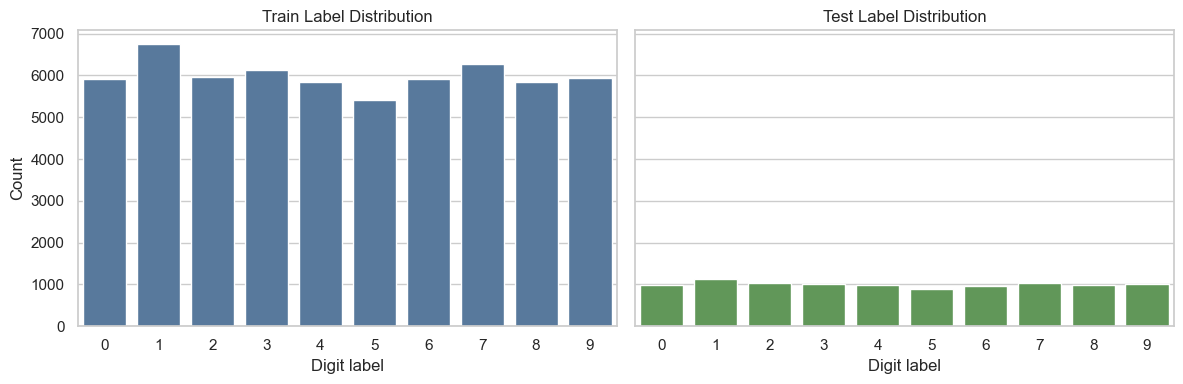

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], color="#4C78A8")
axes[0].set_title("Train Label Distribution")
axes[0].set_xlabel("Digit label")
axes[0].set_ylabel("Count")

sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], color="#59A14F")
axes[1].set_title("Test Label Distribution")
axes[1].set_xlabel("Digit label")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 3) Merge Full Dataset and Check Overall Statistics

In [8]:
x_all, y_all = load_mnist(str(data_path))

print("Merged image array shape:", x_all.shape)
print("Merged label array shape:", y_all.shape)
print("Image dtype:", x_all.dtype)
print("Pixel range:", int(x_all.min()), "to", int(x_all.max()))
print("Number of unique labels:", np.unique(y_all).size)
print("Unique labels:", np.unique(y_all))

Merged image array shape: (70000, 28, 28)
Merged label array shape: (70000,)
Image dtype: uint8
Pixel range: 0 to 255
Number of unique labels: 10
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [9]:
overall_counts = pd.Series(y_all).value_counts().sort_index()
overall_df = pd.DataFrame({"count": overall_counts})
overall_df["percent"] = 100 * overall_df["count"] / overall_df["count"].sum()
overall_df

,count,percent
0,6903,9.861429
1,7877,11.252857
2,6990,9.985714
3,7141,10.201429
4,6824,9.748571
5,6313,9.018571
6,6876,9.822857
7,7293,10.418571
8,6825,9.750000
9,6958,9.940000


## 4) Visualize Samples as Images

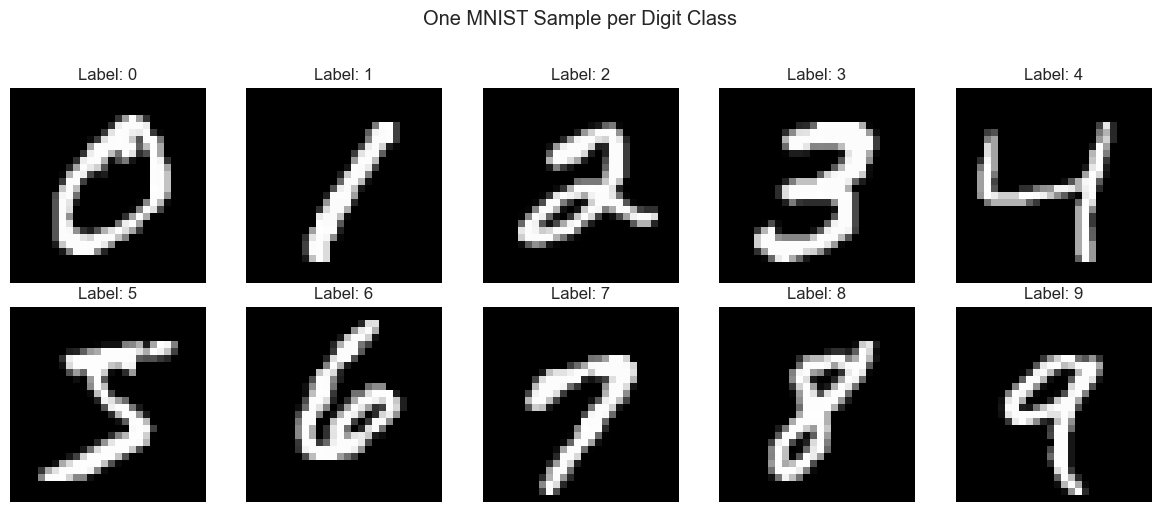

In [10]:
# One sample per digit label
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for digit in range(10):
    idx = np.where(y_all == digit)[0][0]
    axes[digit].imshow(x_all[idx], cmap="gray")
    axes[digit].set_title(f"Label: {digit}")
    axes[digit].axis("off")

plt.suptitle("One MNIST Sample per Digit Class", y=1.02)
plt.tight_layout()
plt.show()

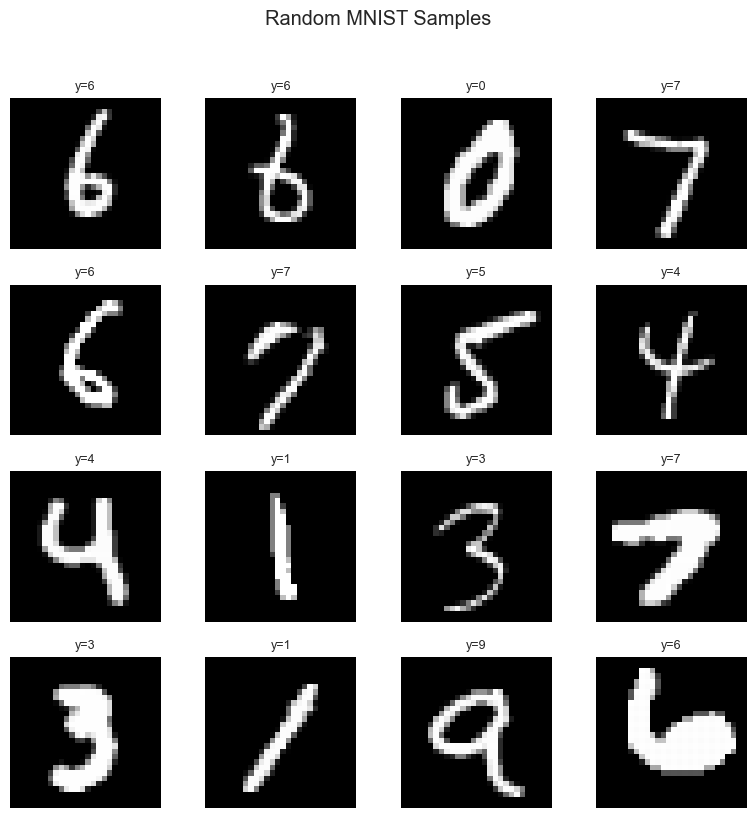

In [11]:
# Random samples from full dataset
rng = np.random.default_rng(42)
sample_ids = rng.choice(x_all.shape[0], size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, idx in zip(axes.ravel(), sample_ids):
    ax.imshow(x_all[idx], cmap="gray")
    ax.set_title(f"y={int(y_all[idx])}", fontsize=9)
    ax.axis("off")

plt.suptitle("Random MNIST Samples", y=1.02)
plt.tight_layout()
plt.show()

## 5) Pixel-Level Inspection

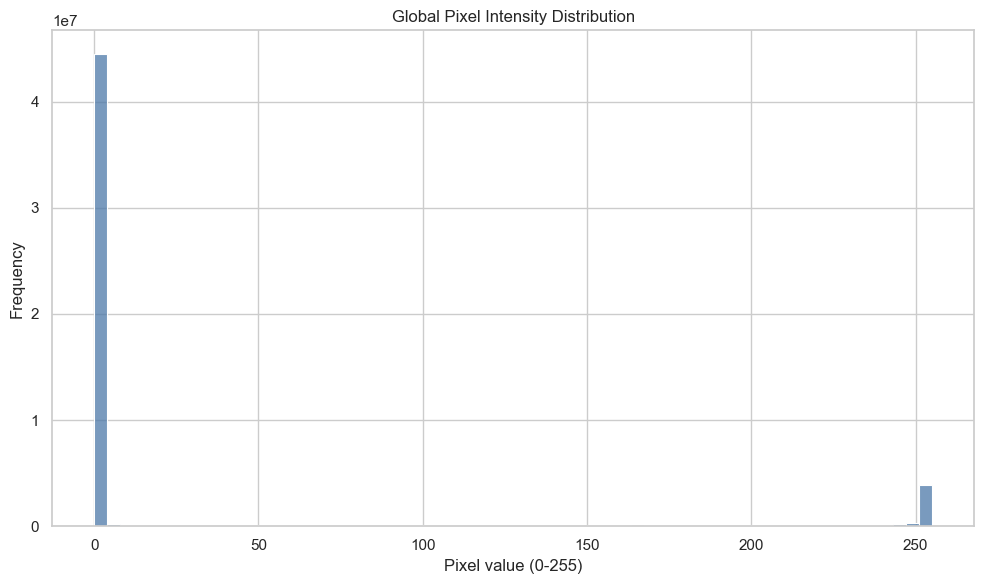

Pixel mean: 33.385964741253645
Pixel std: 78.6543736268941
Unique count: 256
First 20: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Last 20: [236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253
 254 255]


In [30]:
# Distribution of pixel intensities over all images
pixel_values = x_all.reshape(-1)

plt.figure(figsize=(10, 6))
sns.histplot(pixel_values, bins=64, color="#4C78A8")
plt.title("Global Pixel Intensity Distribution")
plt.xlabel("Pixel value (0-255)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Pixel mean:", float(pixel_values.mean()))
print("Pixel std:", float(pixel_values.std()))

unique_vals = np.unique(pixel_values)
print("Unique count:", unique_vals.size)
print("First 20:", unique_vals[:20])
print("Last 20:", unique_vals[-20:])

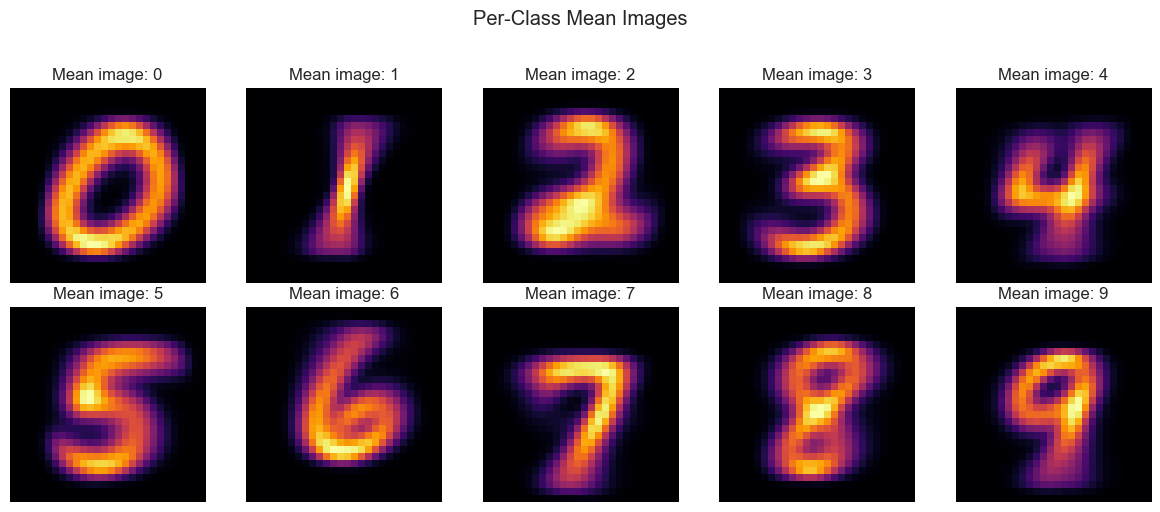

In [13]:
# Average image for each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for digit in range(10):
    mean_img = x_all[y_all == digit].mean(axis=0)
    axes[digit].imshow(mean_img, cmap="inferno")
    axes[digit].set_title(f"Mean image: {digit}")
    axes[digit].axis("off")

plt.suptitle("Per-Class Mean Images", y=1.02)
plt.tight_layout()
plt.show()

## 9) Final Notes

This notebook now shows:
- raw file structure and all arrays
- label distributions in train/test and merged data
- sample images and per-class mean images
- pixel intensity statistics
- binary subset extraction
- exact train/validation/test split composition
- normalization, flattening, PCA, and HOG feature prep examples

In [14]:
class_a, class_b = 0, 1
x_binary, y_binary = select_binary_classes(x_all, y_all, class_a, class_b)

print(f"Binary classes: {class_a} vs {class_b}")
print("Binary image shape:", x_binary.shape)
print("Binary label shape:", y_binary.shape)
print("Counts:", pd.Series(y_binary).value_counts().sort_index().to_dict())

Binary classes: 0 vs 1
Binary image shape: (14780, 28, 28)
Binary label shape: (14780,)
Counts: {0: 6903, 1: 7877}


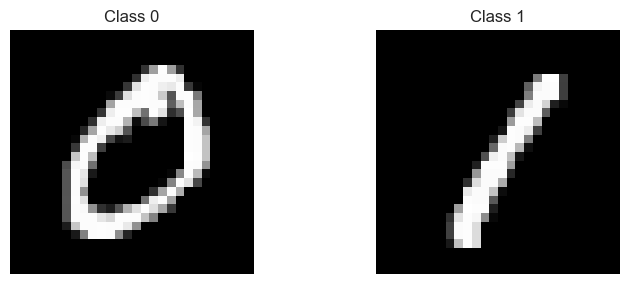

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, cls in enumerate([class_a, class_b]):
    idx = np.where(y_binary == cls)[0][0]
    axes[i].imshow(x_binary[idx], cmap="gray")
    axes[i].set_title(f"Class {cls}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 7) How Data Is Divided (Train/Validation/Test)

In [16]:
test_size = 0.2
val_size = 0.2
random_state = 42

x_train, x_val, x_test, y_train, y_val, y_test = split_data(
    x_binary,
    y_binary,
    test_size=test_size,
    val_size=val_size,
    random_state=random_state,
)

split_stats = pd.DataFrame(
    [
        {
            "split": "train",
            "samples": x_train.shape[0],
            "class_0": int((y_train == class_a).sum()),
            "class_1": int((y_train == class_b).sum()),
        },
        {
            "split": "validation",
            "samples": x_val.shape[0],
            "class_0": int((y_val == class_a).sum()),
            "class_1": int((y_val == class_b).sum()),
        },
        {
            "split": "test",
            "samples": x_test.shape[0],
            "class_0": int((y_test == class_a).sum()),
            "class_1": int((y_test == class_b).sum()),
        },
    ]
)
split_stats["class_0_pct"] = 100 * split_stats["class_0"] / split_stats["samples"]
split_stats["class_1_pct"] = 100 * split_stats["class_1"] / split_stats["samples"]
split_stats

,split,samples,class_0,class_1,class_0_pct,class_1_pct
0,train,8868,4141,4727,46.695986,53.304014
1,validation,2956,1381,1575,46.718539,53.281461
2,test,2956,1381,1575,46.718539,53.281461


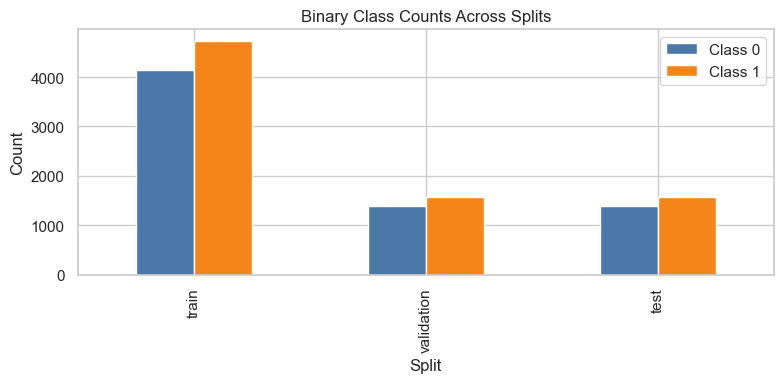

In [17]:
split_plot_df = split_stats.set_index("split")[["class_0", "class_1"]]
ax = split_plot_df.plot(kind="bar", figsize=(8, 4), color=["#4C78A8", "#F58518"])
ax.set_title("Binary Class Counts Across Splits")
ax.set_xlabel("Split")
ax.set_ylabel("Count")
ax.legend([f"Class {class_a}", f"Class {class_b}"])
plt.tight_layout()
plt.show()

## 8) Feature Preparation Extras

These examples summarize the data-prep steps used in the older notebooks:
- normalize pixel values to `[0, 1]`
- flatten images for classical models
- create PCA and HOG feature sets for experimentation
- show the same data can also be reused for multiclass work

In [ ]:
# Normalize the binary split and prepare a few classical feature views
x_train_norm = x_train.astype(np.float32) / 255.0
x_val_norm = x_val.astype(np.float32) / 255.0
x_test_norm = x_test.astype(np.float32) / 255.0

x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_val_flat = x_val_norm.reshape(x_val_norm.shape[0], -1)
x_test_flat = x_test_norm.reshape(x_test_norm.shape[0], -1)

scaler_flat = StandardScaler()
x_train_flat = scaler_flat.fit_transform(x_train_flat)
x_val_flat = scaler_flat.transform(x_val_flat)
x_test_flat = scaler_flat.transform(x_test_flat)

print("Normalized train range:", float(x_train_norm.min()), "to", float(x_train_norm.max()))
print("Flattened train shape:", x_train_flat.shape)
print("Flattened validation shape:", x_val_flat.shape)
print("Flattened test shape:", x_test_flat.shape)

In [ ]:
# PCA reduces the flattened vectors while preserving most variance
pca = PCA(n_components=0.95, random_state=42)
x_train_pca = pca.fit_transform(x_train_flat)
x_val_pca = pca.transform(x_val_flat)
x_test_pca = pca.transform(x_test_flat)

print("PCA components retained:", pca.n_components_)
print("PCA train shape:", x_train_pca.shape)
print("PCA validation shape:", x_val_pca.shape)
print("PCA test shape:", x_test_pca.shape)

# HOG keeps local shape/edge information
def extract_hog_batch(images):
    features = []
    for image in images:
        feature_vector = hog(
            image,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            feature_vector=True,
        )
        features.append(feature_vector)
    return np.asarray(features)

x_train_hog = extract_hog_batch(x_train_norm)
x_val_hog = extract_hog_batch(x_val_norm)
x_test_hog = extract_hog_batch(x_test_norm)

scaler_hog = StandardScaler()
x_train_hog = scaler_hog.fit_transform(x_train_hog)
x_val_hog = scaler_hog.transform(x_val_hog)
x_test_hog = scaler_hog.transform(x_test_hog)

print("HOG train shape:", x_train_hog.shape)
print("HOG validation shape:", x_val_hog.shape)
print("HOG test shape:", x_test_hog.shape)

## 9) Final Notes

This notebook shows:
- raw file structure and all arrays
- label distributions in train/test and merged data
- sample images and per-class mean images
- pixel intensity statistics
- binary subset extraction
- exact train/validation/test split composition
- normalization, flattening, PCA, and HOG feature prep examples